In [1]:
# LOAD Packages (copied from initial training script)
import numpy as np
from collections import namedtuple, OrderedDict
import sys
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')
sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils/')
from utils.parse_yaml import ParseYAML
from plot_sheep_tests import TestedSheep

import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import os
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import h5py
import glob
import os
import argparse
import csv
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.axes import Axes
from scipy.stats import linregress, skew, kurtosis


In [2]:
test_dir = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/'
all_config = 'test'
all_train_config = 'default'
all_results_dir = './outputs'
all_num_energy_bins = 20
all_num_ve_frac_bins = 10

mselin_version = 'MSE Loss | E/1000 Target'
mselin_run_num = 'ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-BUGFIX'
mselin_ckpt_file = 'ckpt_epoch_87_iters_2200_best.tar'
mselin_csv_file = test_dir+mselin_run_num+'/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-BUGFIX_test_ckpt_epoch_87_iters_2200_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', mselin_csv_file, '--version', mselin_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', mselin_run_num, '--checkpoint_file', mselin_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

mse_lin = TestedSheep(args)
mse_lin.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [3]:
mselog_version = 'MSE Loss | log(E) Target'
mselog_run_num = 'ddp-shifter-MSELOSS-LogEnergyScale-100kSamples'
mselog_ckpt_file = 'ckpt_epoch_85_iters_2150_best.tar'
mselog_csv_file = test_dir+mselog_run_num+'/logs/ddp-shifter-MSELOSS-LogEnergyScale-100kSamples_test_ckpt_epoch_85_iters_2150_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', mselog_csv_file, '--version', mselog_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', mselog_run_num, '--checkpoint_file', mselog_ckpt_file,'--num_energy_bins', '20']

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

mse_log = TestedSheep(args)
mse_log.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [5]:
l1lin_version = 'L1 Loss | E/1000 Target'
l1lin_run_num = 'ddp-shifter-L1LOSS-LinearEnergyScale-100kSamples'
l1lin_ckpt_file = 'ckpt_epoch_98_iters_2475_best.tar'
l1lin_csv_file = test_dir+l1lin_run_num+'/logs/ddp-shifter-L1LOSS-LinearEnergyScale-100kSamples_test_ckpt_epoch_98_iters_2475_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', l1lin_csv_file, '--version', l1lin_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', l1lin_run_num, '--checkpoint_file', l1lin_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

l1_lin = TestedSheep(args)
l1_lin.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [6]:
l1log_version = 'L1 Loss | log(E) Target'
l1log_run_num = 'ddp-shifter-L1LOSS-LogEnergyScale-100kSamples'
l1log_ckpt_file = 'ckpt_epoch_68_iters_1725_best.tar'
l1log_csv_file = test_dir+l1log_run_num+'/logs/ddp-shifter-L1LOSS-LogEnergyScale-100kSamples_test_ckpt_epoch_68_iters_1725_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', l1log_csv_file, '--version', l1log_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', l1log_run_num, '--checkpoint_file', l1log_ckpt_file,'--num_energy_bins', '20']

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

l1_log = TestedSheep(args)
l1_log.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [7]:
huberlin_version = 'Huber Loss | E/1000 Target'
huberlin_run_num = 'ddp-shifter-HUBERLOSS-LinearEnergyScale-100kSamples'
huberlin_ckpt_file = 'ckpt_epoch_95_iters_2400_best.tar'
huberlin_csv_file = test_dir+huberlin_run_num+'/logs/ddp-shifter-HUBERLOSS-LinearEnergyScale-100kSamples_test_ckpt_epoch_95_iters_2400_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', huberlin_csv_file, '--version', huberlin_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', huberlin_run_num, '--checkpoint_file', huberlin_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

huber_lin = TestedSheep(args)
huber_lin.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [8]:
huberlog_version = 'Huber Loss | log(E) Target'
huberlog_run_num = 'ddp-shifter-HUBERLOSS-LogEnergyScale-100kSamples'
huberlog_ckpt_file = 'ckpt_epoch_95_iters_2400_best.tar'
huberlog_csv_file = test_dir+huberlog_run_num+'/logs/ddp-shifter-HUBERLOSS-LogEnergyScale-100kSamples_test_ckpt_epoch_95_iters_2400_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', huberlog_csv_file, '--version', huberlog_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', huberlog_run_num, '--checkpoint_file', huberlog_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

huber_log = TestedSheep(args)
huber_log.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [9]:
mselinLRinc_version = 'MSE Loss | E/1000 Target | LR Scheduler'
mselinLRinc_run_num = 'ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p0001'
mselinLRinc_ckpt_file = 'ckpt_epoch_90_iters_2275_best.tar'
mselinLRinc_csv_file = test_dir+mselinLRinc_run_num+'/logs/ddp-shifter-MSELOSS-LinearEnergyScale-100kSamples-LR_SCHEDULE_20_0p0001_test_ckpt_epoch_90_iters_2275_best_log.csv'

sys.argv = ['plot_sheep_tests.py', '--csv_file', mselinLRinc_csv_file, '--version', mselinLRinc_version, '--config', 'test', '--train_config', 'default', '--results_dir', './outputs', '--run_num', mselinLRinc_run_num, '--checkpoint_file', mselinLRinc_ckpt_file]

parser = argparse.ArgumentParser()
parser.add_argument("--csv_file", default='test_results.csv', type=str, help='csv file with test results')
parser.add_argument("--version", default='MSE Loss / E/1000 Target', type=str, help='csv file with test results')
parser.add_argument("--config", default='test', type=str)
parser.add_argument("--train_config", default='default', type=str)
parser.add_argument("--results_dir", default='./outputs', type=str, help='directory to store results')
parser.add_argument("--run_num", default='0', type=str, help='sub run config')
parser.add_argument("--checkpoint_file", default='ckpt_best.tar', type=str, help='checkpoint file to load')
parser.add_argument("--num_energy_bins", default=20, type=int, help='number of energy bins for plots')
parser.add_argument("--num_ve_frac_bins", default=10, type=int, help='number of visible energy fraction bins for plots')
args = parser.parse_args()

mse_linLRinc = TestedSheep(args)
mse_linLRinc.run()

/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:301: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ebins[i]:.0f}-{self.ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {pred_res_skew:.2f}\nKurtosis: {pred_res_kurtosis:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))
/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/plot_sheep_tests.py:364: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{self.ve_frac_bins[i]:.2f}-{self.ve_frac_bins[i+1]:.2f} \n{frac_events_per_ve_frac_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd 

In [40]:
tested_sheeps = [mse_lin, mse_log, l1_lin, l1_log, huber_lin, huber_log, mse_linLRinc]
num_sheeps = len(tested_sheeps)
num_ebins = int(tested_sheeps[0].num_energy_bins)
ebins= tested_sheeps[0].ebins
num_ve_frac_bins = int(tested_sheeps[0].num_ve_frac_bins)
ve_frac_bins = tested_sheeps[0].ve_frac_bins

labels = [sheep.version for sheep in tested_sheeps]

true_vs_pred_res_slopes = [sheep.true_vs_pred_res_slope for sheep in tested_sheeps]
true_vs_pred_res_intercepts = [sheep.true_vs_pred_res_intercept for sheep in tested_sheeps]
true_vs_pred_res_r2 = [sheep.true_vs_pred_res_r2 for sheep in tested_sheeps]

pred_total_res_gauss_fit_means = [sheep.pred_total_res_gauss_fit_mean for sheep in tested_sheeps]
pred_total_res_gauss_fit_stds = [sheep.pred_total_res_gauss_fit_std for sheep in tested_sheeps]
pred_res_total_skews = [sheep.pred_res_total_skew for sheep in tested_sheeps]
pred_res_total_kurtoses = [sheep.pred_res_total_kurtosis for sheep in tested_sheeps]

# By energy /ve frac bin

true_vs_pred_res_slopes_by_ve_frac_bins = np.zeros((num_sheeps, num_ve_frac_bins))
true_vs_pred_res_intercepts_by_ve_frac_bins = np.zeros((num_sheeps, num_ve_frac_bins))
true_vs_pred_res_r2_by_ve_frac_bins = np.zeros((num_sheeps, num_ve_frac_bins))

for i in range(num_sheeps):
    true_vs_pred_res_slopes_by_ve_frac_bins[i,:] = tested_sheeps[i].true_vs_pred_res_slope_by_ve_frac_bin
    true_vs_pred_res_intercepts_by_ve_frac_bins[i,:] = tested_sheeps[i].true_vs_pred_res_intercept_by_ve_frac_bin
    true_vs_pred_res_r2_by_ve_frac_bins[i,:] = tested_sheeps[i].true_vs_pred_res_r2_by_ve_frac_bin
#print(true_vs_pred_res_slopes_by_ve_frac_bins)

pred_total_res_gauss_fit_means_by_ebins = np.zeros((num_sheeps, num_ebins))
pred_total_res_gauss_fit_stds_by_ebins = np.zeros((num_sheeps, num_ebins))
pred_res_total_skews_by_ebins = np.zeros((num_sheeps, num_ebins))
pred_res_total_kurtoses_by_ebins = np.zeros((num_sheeps, num_ebins))

for i in range(num_sheeps):
    pred_total_res_gauss_fit_means_by_ebins[i,:] = tested_sheeps[i].pred_res_gauss_fit_mean_by_ebin
    pred_total_res_gauss_fit_stds_by_ebins[i,:] = tested_sheeps[i].pred_res_gauss_fit_std_by_ebin
    pred_res_total_skews_by_ebins[i,:] = tested_sheeps[i].pred_res_skew_by_ebin
    pred_res_total_kurtoses_by_ebins[i,:] = tested_sheeps[i].pred_res_kurtosis_by_ebin


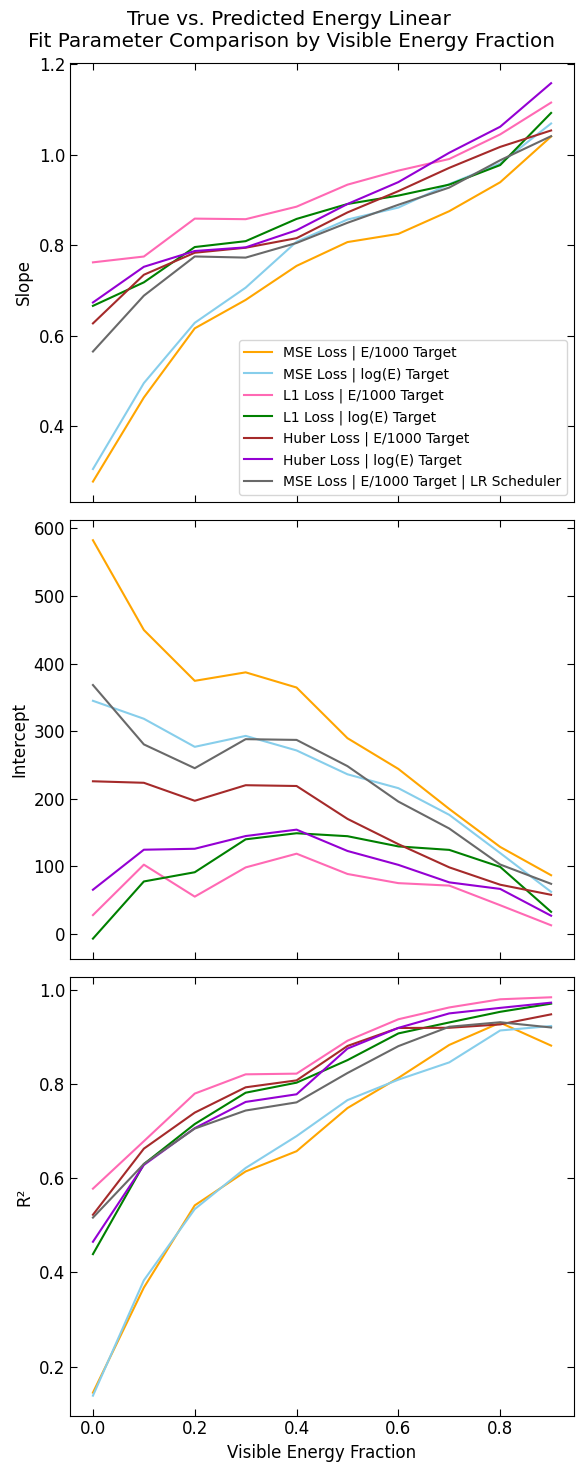

In [48]:
colors = ['orange', 'skyblue', 'hotpink', 'green', 'brown', 'darkviolet', 'dimgrey']
fig, ax = plt.subplots(3,1,figsize=(6,15), sharex=True)

for i in range(num_sheeps):
    ax[0].plot(ve_frac_bins[:-1],true_vs_pred_res_slopes_by_ve_frac_bins[i], color=colors[i], label=labels[i])
    ax[1].plot(ve_frac_bins[:-1],true_vs_pred_res_intercepts_by_ve_frac_bins[i], color=colors[i], label=labels[i])
    ax[2].plot(ve_frac_bins[:-1],true_vs_pred_res_r2_by_ve_frac_bins[i], color=colors[i], label=labels[i])

ax[0].set_ylabel('Slope')
ax[2].set_xlabel('Visible Energy Fraction')

ax[1].set_ylabel('Intercept')
ax[0].legend(fontsize=10)

ax[2].set_ylabel('R²')
fig.suptitle('True vs. Predicted Energy Linear \nFit Parameter Comparison by Visible Energy Fraction')

fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/linear_fit_comp_test_by_energy_bin.png')

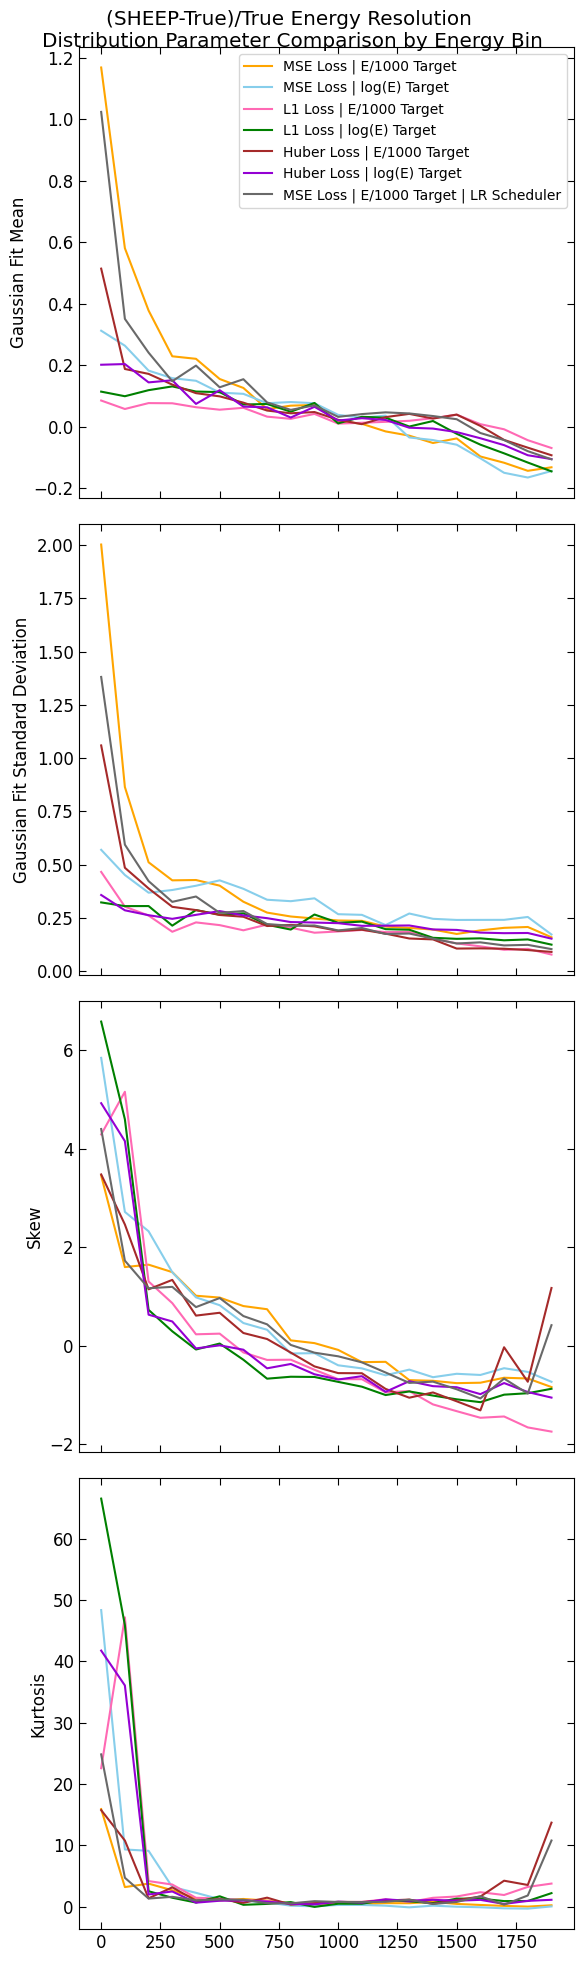

In [51]:
fig, ax = plt.subplots(4,1,figsize=(6,20), sharex=True)

for i in range(num_sheeps):
    ax[0].plot(ebins[:-1],pred_total_res_gauss_fit_means_by_ebins[i], color=colors[i], label=labels[i])
    ax[1].plot(ebins[:-1],pred_total_res_gauss_fit_stds_by_ebins[i], color=colors[i], label=labels[i])
    ax[2].plot(ebins[:-1],pred_res_total_skews_by_ebins[i], color=colors[i], label=labels[i])
    ax[3].plot(ebins[:-1],pred_res_total_kurtoses_by_ebins[i], color=colors[i], label=labels[i])


ax[0].legend(fontsize=10)

#ax[0].scatter(labels, pred_total_res_gauss_fit_means)
ax[0].set_ylabel('Gaussian Fit Mean')
ax[3].set_xlabel('True Energy Bin [MeV]')

#ax[1].scatter(labels,pred_total_res_gauss_fit_stds)
ax[1].set_ylabel('Gaussian Fit Standard Deviation')

#ax[2].scatter(labels,pred_res_total_skews)
ax[2].set_ylabel('Skew')

#ax[3].scatter(labels,pred_res_total_kurtoses)
ax[3].set_ylabel('Kurtosis')
fig.suptitle('(SHEEP-True)/True Energy Resolution \nDistribution Parameter Comparison by Energy Bin')

fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/pred_gaus_fit_comp_test_by_energy_bin.png')

/tmp/ipykernel_2340973/3398087006.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(labels, rotation=30, ha='right')


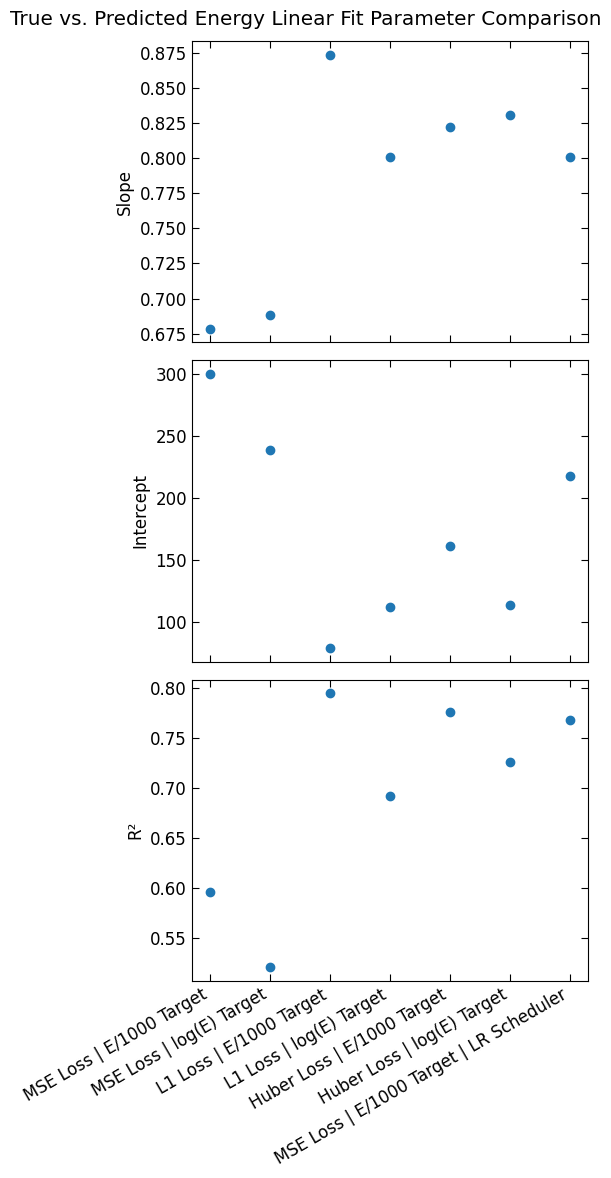

In [26]:
# Compare Res Slopes and intercepts and r^2
fig, ax = plt.subplots(3,1,figsize=(6,12), sharex=True)
ax[0].scatter(labels, true_vs_pred_res_slopes)
ax[0].set_ylabel('Slope')
#ax[2].set_xlabel('SHEEP Model Version')
ax[2].set_xticklabels(labels, rotation=30, ha='right') 

ax[1].scatter(labels,true_vs_pred_res_intercepts)
ax[1].set_ylabel('Intercept')

ax[2].scatter(labels,true_vs_pred_res_r2)
ax[2].set_ylabel('R²')
fig.suptitle('True vs. Predicted Energy Linear Fit Parameter Comparison')
fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/linear_fit_comp_test.png')


/tmp/ipykernel_2340973/2135458723.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3].set_xticklabels(labels, rotation=30, ha='right')


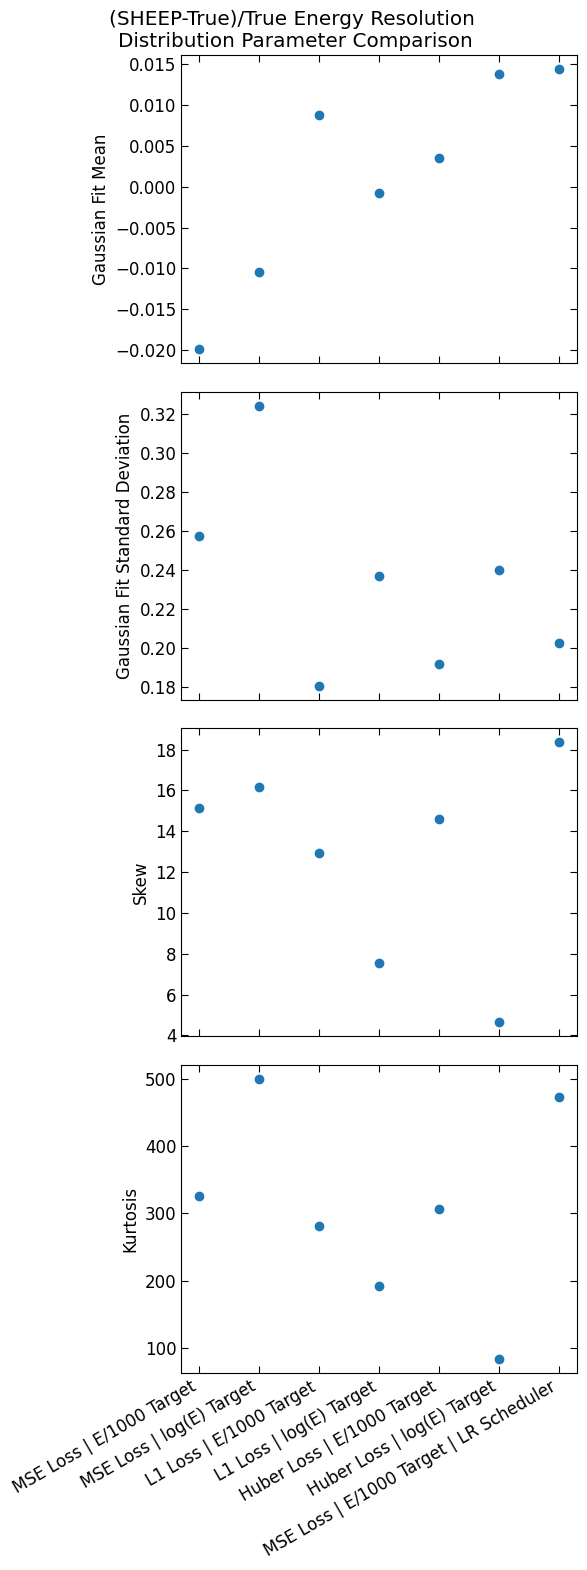

In [33]:
# Compare Gaus Fit and Skew and Kurtosis
fig, ax = plt.subplots(4,1,figsize=(6,16), sharex=True)
ax[0].scatter(labels, pred_total_res_gauss_fit_means)
ax[0].set_ylabel('Gaussian Fit Mean')
#ax[2].set_xlabel('SHEEP Model Version')
ax[3].set_xticklabels(labels, rotation=30, ha='right') 

ax[1].scatter(labels,pred_total_res_gauss_fit_stds)
ax[1].set_ylabel('Gaussian Fit Standard Deviation')

ax[2].scatter(labels,pred_res_total_skews)
ax[2].set_ylabel('Skew')

ax[3].scatter(labels,pred_res_total_kurtoses)
ax[3].set_ylabel('Kurtosis')
fig.suptitle('(SHEEP-True)/True Energy Resolution \nDistribution Parameter Comparison')
fig.tight_layout()
#plt.show()
plt.savefig('/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/test/comparisons/pred_gaus_fit_total_comp_test.png')

Skew: 16.171918410816097
Kurtosis: 499.8857823307499


Text(-1.88, 0.267, 'MSE Loss | log(E) Target')

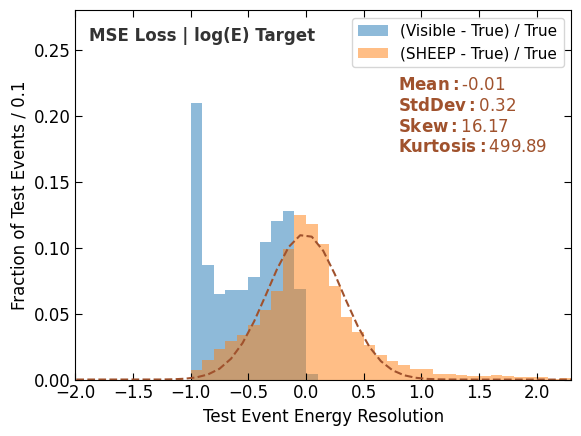

In [12]:
from scipy.optimize import curve_fit
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))


plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'legend.fontsize': 12})
#plt.rcParams['font.family'] = 'serif'
#plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

res_vis_true = (mse_log.ve - mse_log.labels) / mse_log.labels
res_true_pred = (mse_log.preds - mse_log.labels)/ mse_log.labels
rbins = np.linspace(-10, 10, 201)
num_events=len(res_vis_true)


hist_counts_vis_true, bin_edges_vis_true = np.histogram(res_vis_true, bins=rbins, density=False)
bin_centers_vis_true = (bin_edges_vis_true[:-1] + bin_edges_vis_true[1:]) / 2
initial_guesses_vis_true  = [np.max(hist_counts_vis_true), np.mean(res_vis_true), np.std(res_vis_true)]

hist_counts_true_pred, bin_edges_true_pred = np.histogram(res_true_pred, bins=rbins, density=False)
bin_centers_true_pred = (bin_edges_true_pred[:-1] + bin_edges_true_pred[1:]) / 2
initial_guesses_true_pred  = [np.max(hist_counts_true_pred/num_events), np.mean(res_true_pred), np.std(res_true_pred)]

# Perform the curve fit
vis_true_params, vis_true_covariance = curve_fit(gaussian, bin_centers_vis_true, hist_counts_vis_true, p0=initial_guesses_vis_true)
true_pred_params, true_pred_covariance = curve_fit(gaussian, bin_centers_true_pred, hist_counts_true_pred/num_events, p0=initial_guesses_true_pred)
true_pred_skew = skew(res_true_pred)
print("Skew:", true_pred_skew)
true_pred_kurtosis = kurtosis(res_true_pred)
print("Kurtosis:", true_pred_kurtosis)

plt.hist(bin_edges_vis_true[:-1], bins=bin_edges_vis_true, weights=hist_counts_vis_true/num_events, label="(Visible - True) / True", alpha=0.5, edgecolor="none")
#plt.plot(bin_centers_vis_true, gaussian(bin_centers_vis_true, *vis_true_params), color='blue', linestyle="--")
plt.hist(bin_edges_true_pred[:-1],bins=bin_edges_true_pred, weights=hist_counts_true_pred/num_events, label="(SHEEP - True) / True", alpha=0.5, edgecolor="none")
plt.plot(bin_centers_true_pred, gaussian(bin_centers_true_pred, *true_pred_params), color='sienna', linestyle="--")
plt.legend(fontsize=11)
plt.xlim(-2, 2.3)
plt.ylim(0,0.28)
plt.ylabel("Fraction of Test Events / 0.1")
plt.xlabel("Test Event Energy Resolution")
ax=plt.gca()
ax.text(0.8, 0.23, r"$\mathbf{Mean:}$"+f"{true_pred_params[1]:.2f}\n"+r"$\mathbf{Std Dev:}$"+f"{true_pred_params[2]:.2f}\n"+r"$\mathbf{Skew:}$"+f"{true_pred_skew:.2f}\n"+r"$\mathbf{Kurtosis:}$"+f"{true_pred_kurtosis:.2f}", fontsize=12, verticalalignment='top', color='sienna')
#ax.text(-1.88, 0.267, f"PRELIMINARY", fontsize=18, verticalalignment='top', color='black', alpha=0.35, fontweight='bold')
ax.text(-1.88, 0.267, mse_log.version, fontsize=12, verticalalignment='top', color='black', alpha=0.8, fontweight='bold')

/tmp/ipykernel_1323644/2208736617.py:40: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[i].text(0.63, 0.8, f"{ebins[i]:.0f}-{ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {true_pred_skew_by_ebin:.2f}\nKurtosis: {true_pred_kurtosis_by_ebin:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))


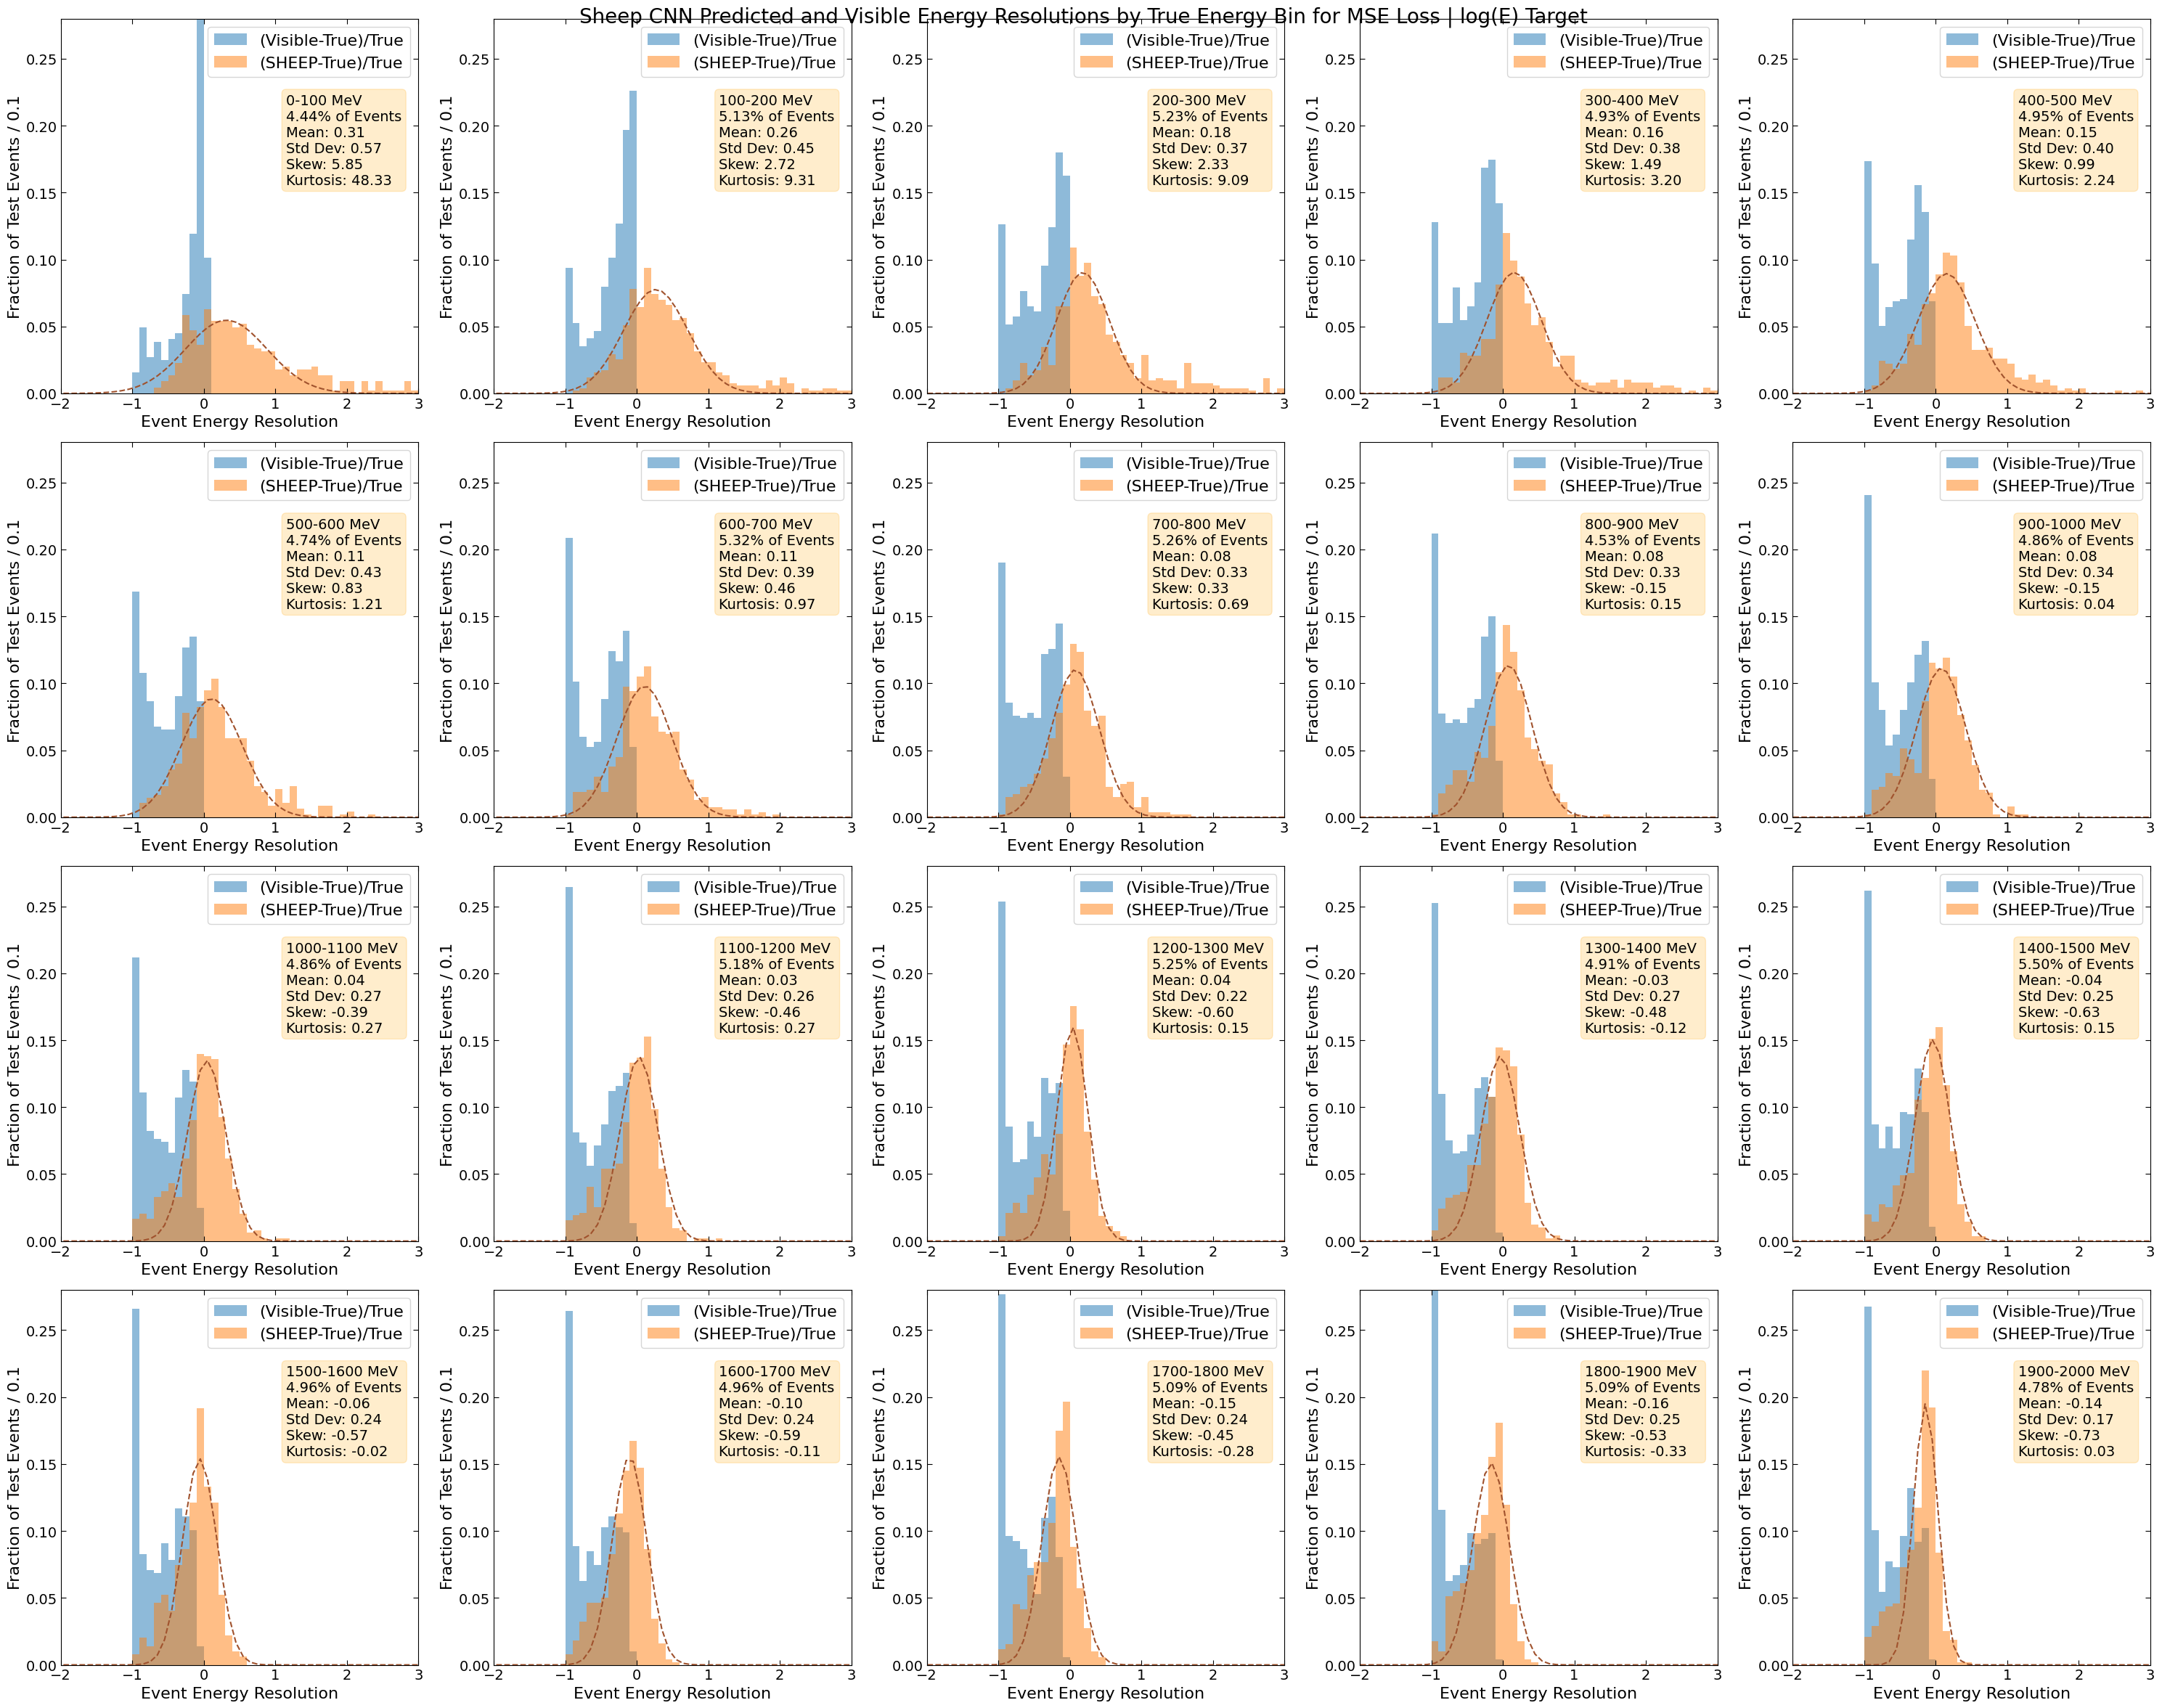

In [13]:
ebins = np.linspace(0, 2000, mse_log.num_energy_bins + 1)
ebin_centers = 0.5 * (ebins[:-1] + ebins[1:])
    
fig, ax = plt.subplots(int(mse_log.num_energy_bins/5),5, figsize=(30, int(6*(mse_log.num_energy_bins/5))))#, sharex=True, sharey=True)
ax = ax.flatten()
rbins = np.linspace(-10, 10, 201)
    
for i in range(mse_log.num_energy_bins):
    bin_mask = (mse_log.labels > ebins[i]) & (mse_log.labels <= ebins[i + 1])
    if np.sum(bin_mask) == 0:
        continue
    ve_bin = mse_log.ve[bin_mask]
    true_bin = mse_log.labels[bin_mask]
    pred_bin =  mse_log.preds[bin_mask]
    res_vis_true = (ve_bin-true_bin) / true_bin
    res_true_pred = (pred_bin-true_bin)/ true_bin
    num_events_per_energy_bin = len(true_bin)
    frac_events_per_energy_bin = (num_events_per_energy_bin/len(mse_log.labels))*100

    hist_counts_vis_true, bin_edges_vis_true = np.histogram(res_vis_true, bins=rbins, density=False)
    bin_centers_vis_true = (bin_edges_vis_true[:-1] + bin_edges_vis_true[1:]) / 2
    initial_guesses_vis_true  = [np.max(hist_counts_vis_true/num_events_per_energy_bin), np.mean(res_vis_true), np.std(res_vis_true)]

    hist_counts_true_pred, bin_edges_true_pred = np.histogram(res_true_pred, bins=rbins, density=False)
    bin_centers_true_pred = (bin_edges_true_pred[:-1] + bin_edges_true_pred[1:]) / 2
    initial_guesses_true_pred  = [np.max(hist_counts_true_pred/num_events_per_energy_bin), np.mean(res_true_pred), np.std(res_true_pred)]
    true_pred_params, true_pred_covariance = curve_fit(gaussian, bin_centers_true_pred, (hist_counts_true_pred/num_events_per_energy_bin), p0=initial_guesses_true_pred)
    true_pred_skew_by_ebin = skew(res_true_pred)
    true_pred_kurtosis_by_ebin = kurtosis(res_true_pred)
        
    ax[i].hist(bin_edges_vis_true[:-1], bins=rbins, weights=hist_counts_vis_true/num_events_per_energy_bin, label=f'(Visible-True)/True', alpha=0.5)
    ax[i].hist(bin_edges_true_pred[:-1], bins=rbins, weights=hist_counts_true_pred/num_events_per_energy_bin, label=f'(SHEEP-True)/True', alpha=0.5)
    ax[i].plot(bin_centers_true_pred, gaussian(bin_centers_true_pred, *true_pred_params), color='sienna', linestyle="--")
    ax[i].set_xlim(-2, 3)
    ax[i].set_ylim(-0, 0.28)
    ax[i].set_xlabel('Event Energy Resolution', fontsize=16)
    ax[i].set_ylabel('Fraction of Test Events / 0.1', fontsize=16)
    ax[i].legend(loc='upper right', fontsize=16)
    ax[i].tick_params(axis='both', which='major', labelsize=14)
    ax[i].text(0.63, 0.8, f"{ebins[i]:.0f}-{ebins[i+1]:.0f} MeV \n{frac_events_per_energy_bin:.2f}% of Events\nMean: {true_pred_params[1]:.2f} \nStd Dev: {true_pred_params[2]:.2f}\nSkew: {true_pred_skew_by_ebin:.2f}\nKurtosis: {true_pred_kurtosis_by_ebin:.2f}", transform=ax[i].transAxes, fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', color='orange', alpha=0.2))

    ax[i].legend(loc='upper right', fontsize=16)
fig.suptitle(f'Sheep CNN Predicted and Visible Energy Resolutions by True Energy Bin for {mse_log.version}', size=20)
fig.tight_layout()
